# 📌라이브러리

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

# 문제 정의

와인 데이터셋에는 산도, 당도, 알코올 등 와인의 화학적 성분 정보가 포함되어있다.<br>
본 프로젝트는 이러한 화학적 특성을 이용하여 와인이 레드와인인지 화이트와인인지 분류하는 모델을 만들 것이다.<br>

# 0.데이터 불러오기

In [14]:
import kagglehub
path = kagglehub.dataset_download("ruthgn/wine-quality-data-set-red-white-wine")

In [15]:
df=pd.read_csv(path+'/wine-quality-white-and-red.csv',encoding='cp949')
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [16]:
print('dataset shape:',df.shape)

dataset shape: (6497, 13)


# 1. 데이터 이해

In [17]:
df.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')

* type: 레드와인인지 화이트 와인인지 구별
* fixed acidity: 고정산도
* volatile acidity: 휘발성 산도
* citric acid: 시트르산(구연산)
* residual sugar: 잔여당분
* chlorides: 염화물
* free sulfur dioxide: 자유 이산화황
* total sulfur dioxide: 총 이산화황
* density: 밀도
* pH: 산성도
* sulphates: 황산염
* alcohol: 알코올도수
* quality: 등급

### 1.2.1 수치형 컬럼의 요약 통계

In [18]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# 2. 전처리

## 2.1 결측치 확인 및 제거

In [19]:
df.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## 2.2 중복 데이터 확인 및 제거
- 모델 학습 시 특정 데이터가 과도하게 반영될 수 있기 때문에 제거해준다

In [20]:
df.duplicated().sum()

np.int64(1177)

In [21]:
df=df.drop_duplicates()
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,white,6.2,0.320,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,red,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### 2.1 Type의 white를 0, red를 1로 변경

In [22]:
df["type"] = df["type"].replace({'white': 0, 'red': 1})
df

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_36336\2778224671.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["type"] = df["type"].replace({'white': 0, 'red': 1})
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_36336\2778224671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["type"] = df["type"].replace({'white': 0, 'red': 1})


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,0,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,0,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,0,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,0,6.2,0.320,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,1,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,1,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,1,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6495,1,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### 2.2 white와 red 분포 확인

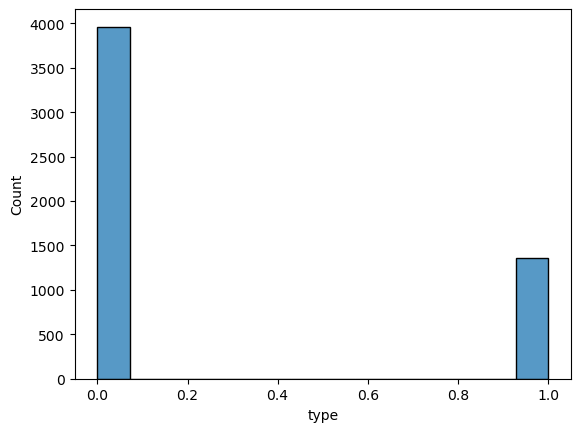

In [23]:
sns.histplot(df,x="type")
plt.show()

# 3. 탐색적 데이터 분석(EDA) 시각화
- EDA를 통해 각 변수의 분포와 변수 간 관계를 파악
- 어떤 특성의 차이를 보이는지 시각화

## 3.1 변수 간 상관관계 확인
- 전체 변수들의 상관관계를 확인하여 어떤 변수들이 서로 비슷한 패턴을 가지는지 살펴본다.
- 상관관계 분석은 변수 간 선형 관계를 파악하는데 유용하고, 특히 목표 변수와 관련성 높은 변수를 찾을 수 있다.

In [24]:
col=df.copy()
df_corr=col.corr()
df_corr

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
type,1.000000,0.486253,0.645335,-0.183759,-0.328695,0.499517,-0.465326,-0.694229,0.429377,0.310919,0.490364,-0.057756,-0.114809
fixed acidity,0.486253,1.000000,0.214752,0.330328,-0.104439,0.288918,-0.281590,-0.327471,0.478180,-0.271182,0.304844,-0.102573,-0.080092
volatile acidity,0.645335,0.214752,1.000000,-0.384192,-0.163696,0.367626,-0.349039,-0.400716,0.308452,0.246687,0.227772,-0.065411,-0.265205
citric acid,-0.183759,0.330328,-0.384192,1.000000,0.146189,0.055199,0.130849,0.194835,0.094758,-0.344735,0.059183,-0.005496,0.097954
residual sugar,-0.328695,-0.104439,-0.163696,0.146189,1.000000,-0.123094,0.398717,0.487519,0.520930,-0.234522,-0.174717,-0.305242,-0.056830
chlorides,0.499517,0.288918,0.367626,0.055199,-0.123094,1.000000,-0.186615,-0.269817,0.371867,0.025823,0.405051,-0.269601,-0.202137
free sulfur dioxide,-0.465326,-0.281590,-0.349039,0.130849,0.398717,-0.186615,1.000000,0.720488,0.006166,-0.141747,-0.198244,-0.170012,0.054002
total sulfur dioxide,-0.694229,-0.327471,-0.400716,0.194835,0.487519,-0.269817,0.720488,1.000000,0.006711,-0.222956,-0.275836,-0.249004,-0.050296
density,0.429377,0.478180,0.308452,0.094758,0.520930,0.371867,0.006166,0.006711,1.000000,0.034273,0.282690,-0.667811,-0.326434
pH,0.310919,-0.271182,0.246687,-0.344735,-0.234522,0.025823,-0.141747,-0.222956,0.034273,1.000000,0.168150,0.097314,0.039733


In [25]:
'''type과 관련된 상관계수 살펴보기'''
df_type_corr=df_corr["type"].sort_values(ascending=False)
df_type_corr

type                    1.000000
volatile acidity        0.645335
chlorides               0.499517
sulphates               0.490364
fixed acidity           0.486253
density                 0.429377
pH                      0.310919
alcohol                -0.057756
quality                -0.114809
citric acid            -0.183759
residual sugar         -0.328695
free sulfur dioxide    -0.465326
total sulfur dioxide   -0.694229
Name: type, dtype: float64

### 🖍피어슨 상관계수 분석
-1.0 < r < -0.7 : 강한 음적 상관관계<br>
-0.7 < r < -0.3 : 뚜렷한 음적 상관관계<br>
-0.3 < r < -0.1 : 약한 음적 상관관계<br>
-0.1 < r < +0.1 : 거의 무시될 수 있는 상관관계<br>
+0.1 < r < +0.3 : 약한 양적 상관관계<br>
+0.3 < r < +0.7 : 뚜렷한 양적 상관관계<br>
+0.7 < r < +1.0 : 강한 양적 상관관계<br>


양적 상관관계는 레드와인 쪽에 가깝고, 음적 상관관계는 화이트와인 쪽에 가깝다.
- volatile acidity    &emsp;뚜렷한 양적 상관관계 <br>
- chlorides           &emsp;뚜렷한 양적 상관관계 <br>
- sulphates           &emsp;뚜렷한 양적 상관관계 <br>
- fixed acidity       &emsp;뚜렷한 양적 상관관계 <br>
- density             &emsp;뚜렷한 양적 상관관계 <br>
- pH                  &emsp;뚜렷한 양적 상관관계 <br>
- alcohol             &emsp;거의 무시될 수 있는 상관관계<br>
- quality             &emsp;약한 음적 상관관계<br>
- citric acid         &emsp;약한 음적 상관관계<br>
- residual sugar      &emsp;뚜렷한 음적 상관관계<br>
- free sulfur dioxide &emsp;뚜렷한 음적 상관관계<br>
- total sulfur dioxide&emsp;뚜렷한 음적 상관관계<br>

volatile acidity, chlorides, sulphates, fixed acidity, density는 절댓값이 높을수록 레드와인일 가능성이 상대적으로 높다.<br>
residual sugar, free sulfur dioxide, total sulfur dioxide는 절댓값이 높을수록 화이트와인일 가능성이 상대적으로 높다.

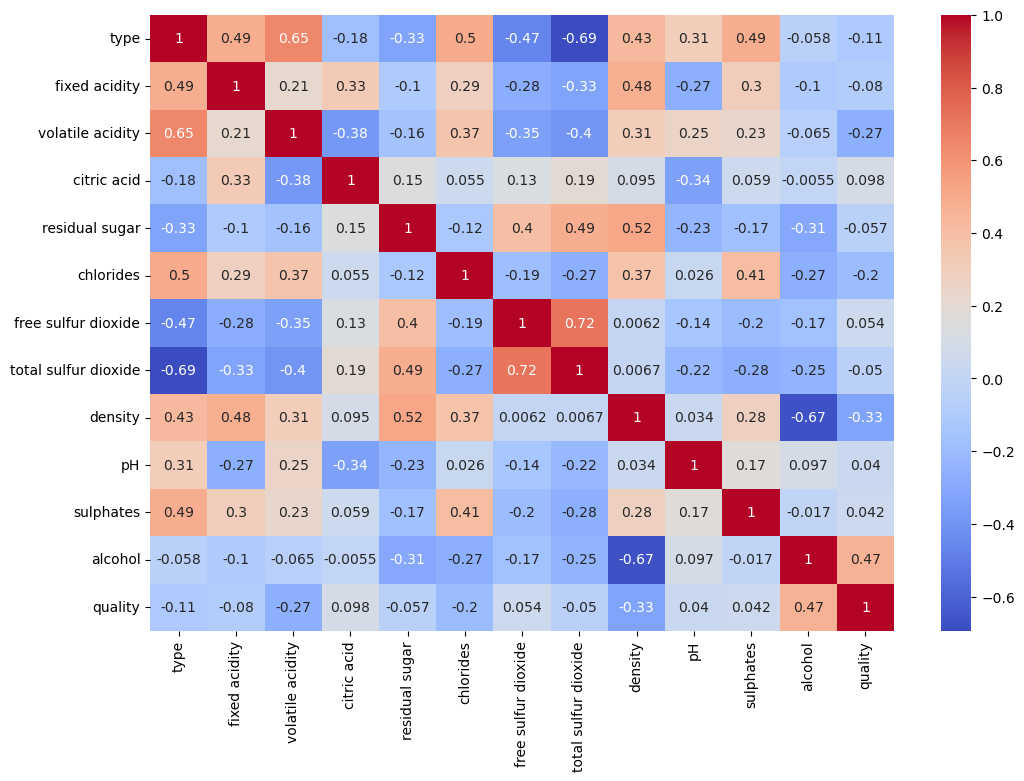

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df_corr,cmap="coolwarm",annot=True)
plt.show()

* free sulfur dioxide - total sulfur dioxide: 0.72 <= 강한 양의 관계
* volatile acidity - critic acid : -0.38 <= 뚜렷한 음의 관계
* density - alcohol : -0.67 <= 뚜렷한 양의 관계

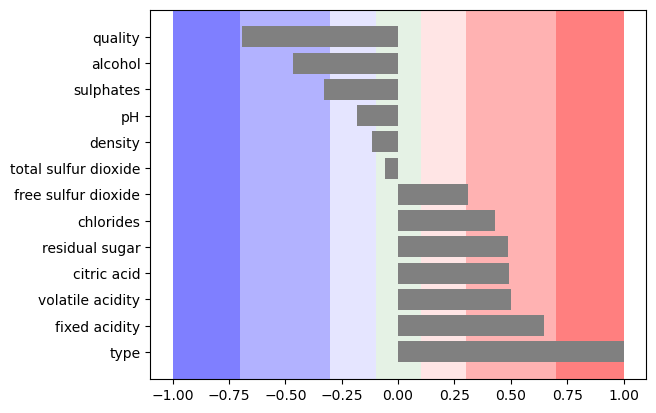

In [27]:
x=col.columns
y=df_type_corr.to_numpy()

plt.axvspan(-1,-0.7,alpha=0.5,facecolor='blue')
plt.axvspan(-0.7,-0.3,alpha=0.3,facecolor='blue')
plt.axvspan(-0.3,-0.1,alpha=0.1,facecolor='blue')
plt.axvspan(-0.1,+0.1,alpha=0.1,facecolor='green')
plt.axvspan(+0.1,+0.3,alpha=0.1,facecolor='red')
plt.axvspan(+0.3,+0.7,alpha=0.3,facecolor='red')
plt.axvspan(+0.7,+1.0,alpha=0.5,facecolor='red')
plt.barh(x,y,color='gray')
plt.show()

In [28]:
df_white=df[df["type"]==0]
df_red=df[df["type"]==1]

In [29]:
cols=df.columns[1:].tolist()
cols

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

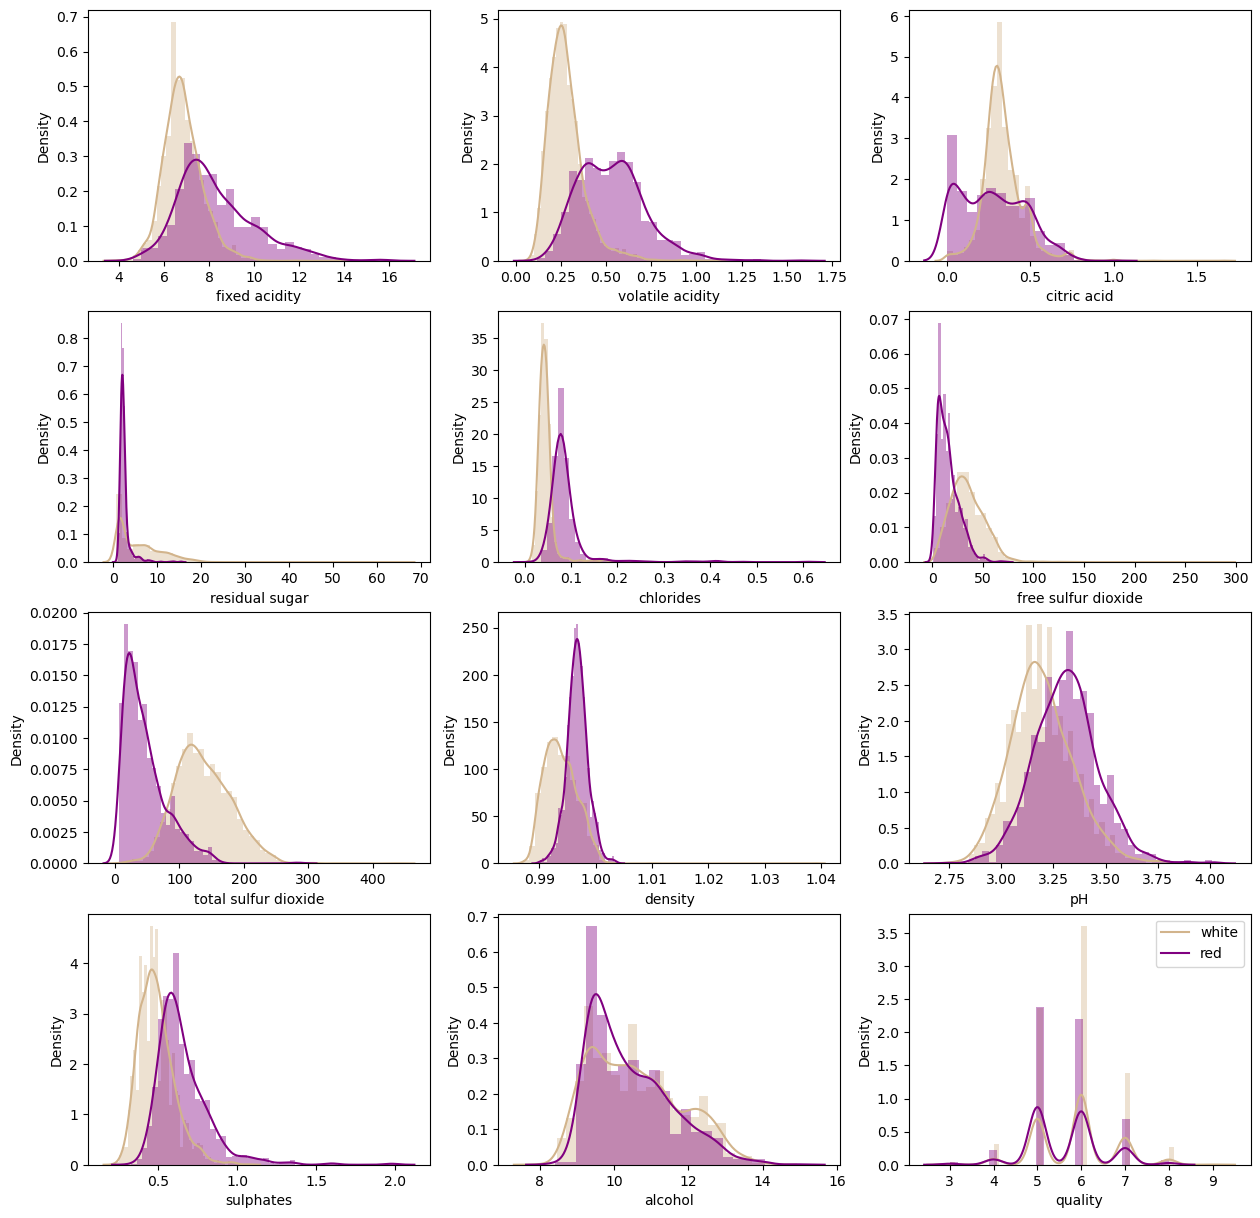

In [30]:
import warnings
warnings.filterwarnings('ignore')
fig, axes= plt.subplots(nrows=4,ncols=3,figsize=(15,15))

for i, col_name in enumerate(cols):
    row=i//3
    col=i%3
    sns.distplot(df_white[col_name],ax=axes[row][col],color='tan')
    sns.distplot(df_red[col_name],ax=axes[row][col],color='purple')
    plt.legend(labels=["white","red"])
plt.show()

레드와인과 화이트와인의 변수 분포를 비교해본 결과, acidity, free sulfur dioxide, total sulfur dioxide에서 레드와인과 화이트와인이 서로 다른 값 범위에 분포하는 경향을 보였다.<br>

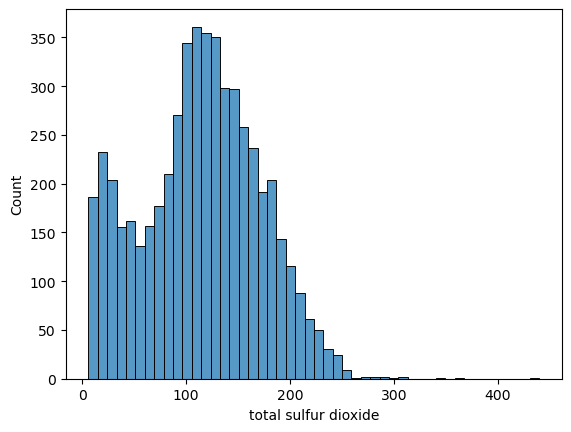

In [31]:
sns.histplot(df['total sulfur dioxide'])
plt.show()

* free sulfur dioxide - total sulfur dioxide: 0.72 <= 강한 양의 관계
* volatile acidity - critic acid : -0.38 <= 뚜렷한 음의 관계
* density - alcohol : -0.67 <= 뚜렷한 양의 관계

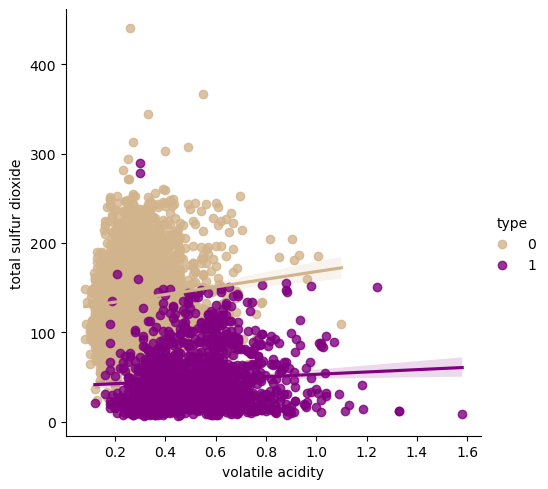

In [32]:
sns.lmplot(df,x="volatile acidity",y="total sulfur dioxide",hue="type", palette=['tan','purple'])
plt.show()

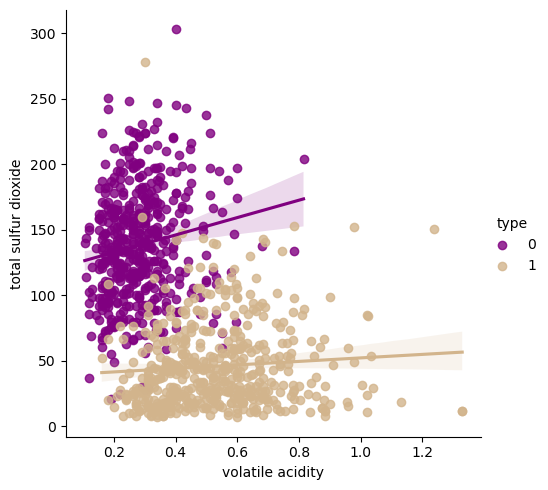

In [33]:
sampled_df = df.groupby('type').apply(lambda x: x.sample(n=min(len(x), 500))).reset_index(drop=True)
sns.lmplot(data=sampled_df, x="volatile acidity",y="total sulfur dioxide",hue="type",  palette=['purple','tan'])
plt.show()

volatile acidity와 total sulfur dioxide의 관계를 시각화한 결과, 레드와 화이트가 서로 다른 영역에 분포하는 경향을 보였다.

In [34]:
df.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')

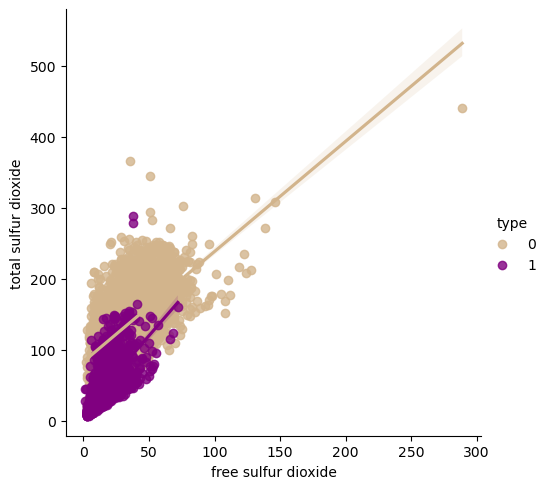

In [35]:
sns.lmplot(df,x="free sulfur dioxide",y="total sulfur dioxide",hue="type", palette=['tan','purple'])
plt.show()

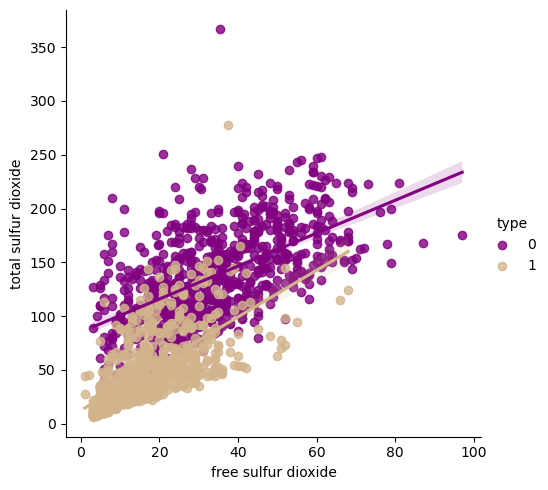

In [36]:
sampled_df = df.groupby('type').apply(lambda x: x.sample(n=min(len(x), 800))).reset_index(drop=True)
sns.lmplot(data=sampled_df, x="free sulfur dioxide",y="total sulfur dioxide",hue="type", palette=['purple','tan'])
plt.show()

free sulfur dioxide와 total sulfur dioxide의 관계를 살펴본 결과, 뚜렷한 양의 관계를 보였으며, 화이트는 전반적으로 total sulfur dioxide에서 높은 영역을, 레드는 상대적으로 낮은 영역에 분포하는 경향을 보였다.

# 4. 모델링

### 4.1 피처 엔지니어링
- X는 데이터 y는 와인 타입으로 분리

In [37]:
X=df.iloc[:,1:]
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,6.2,0.320,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
6491,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


학습을 위해 white을 0, red를 1로 바꾼다.

In [38]:
y=df.iloc[:,0]
y

0       0
1       0
2       0
3       0
6       0
       ..
6491    1
6492    1
6493    1
6495    1
6496    1
Name: type, Length: 5320, dtype: int64

### 4.2 학습

#### - 데이터셋을 80%는 학습용, 20%는 테스트용도로 나눈다

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

모델은 DecisionTree로 선정
- Decision Tree : 비선형 관계의 데이터를 잘 반영함. 분류문제에서 해석이 용이한 경향

In [40]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [41]:
# 위에서 만든 모델로 학습과 예측을 진행해 주세요.
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_predict=model.predict(X_test)
y_predict[:5]

array([1, 0, 1, 0, 0])

In [43]:
feature_names=df.columns[1:]
feature_names

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

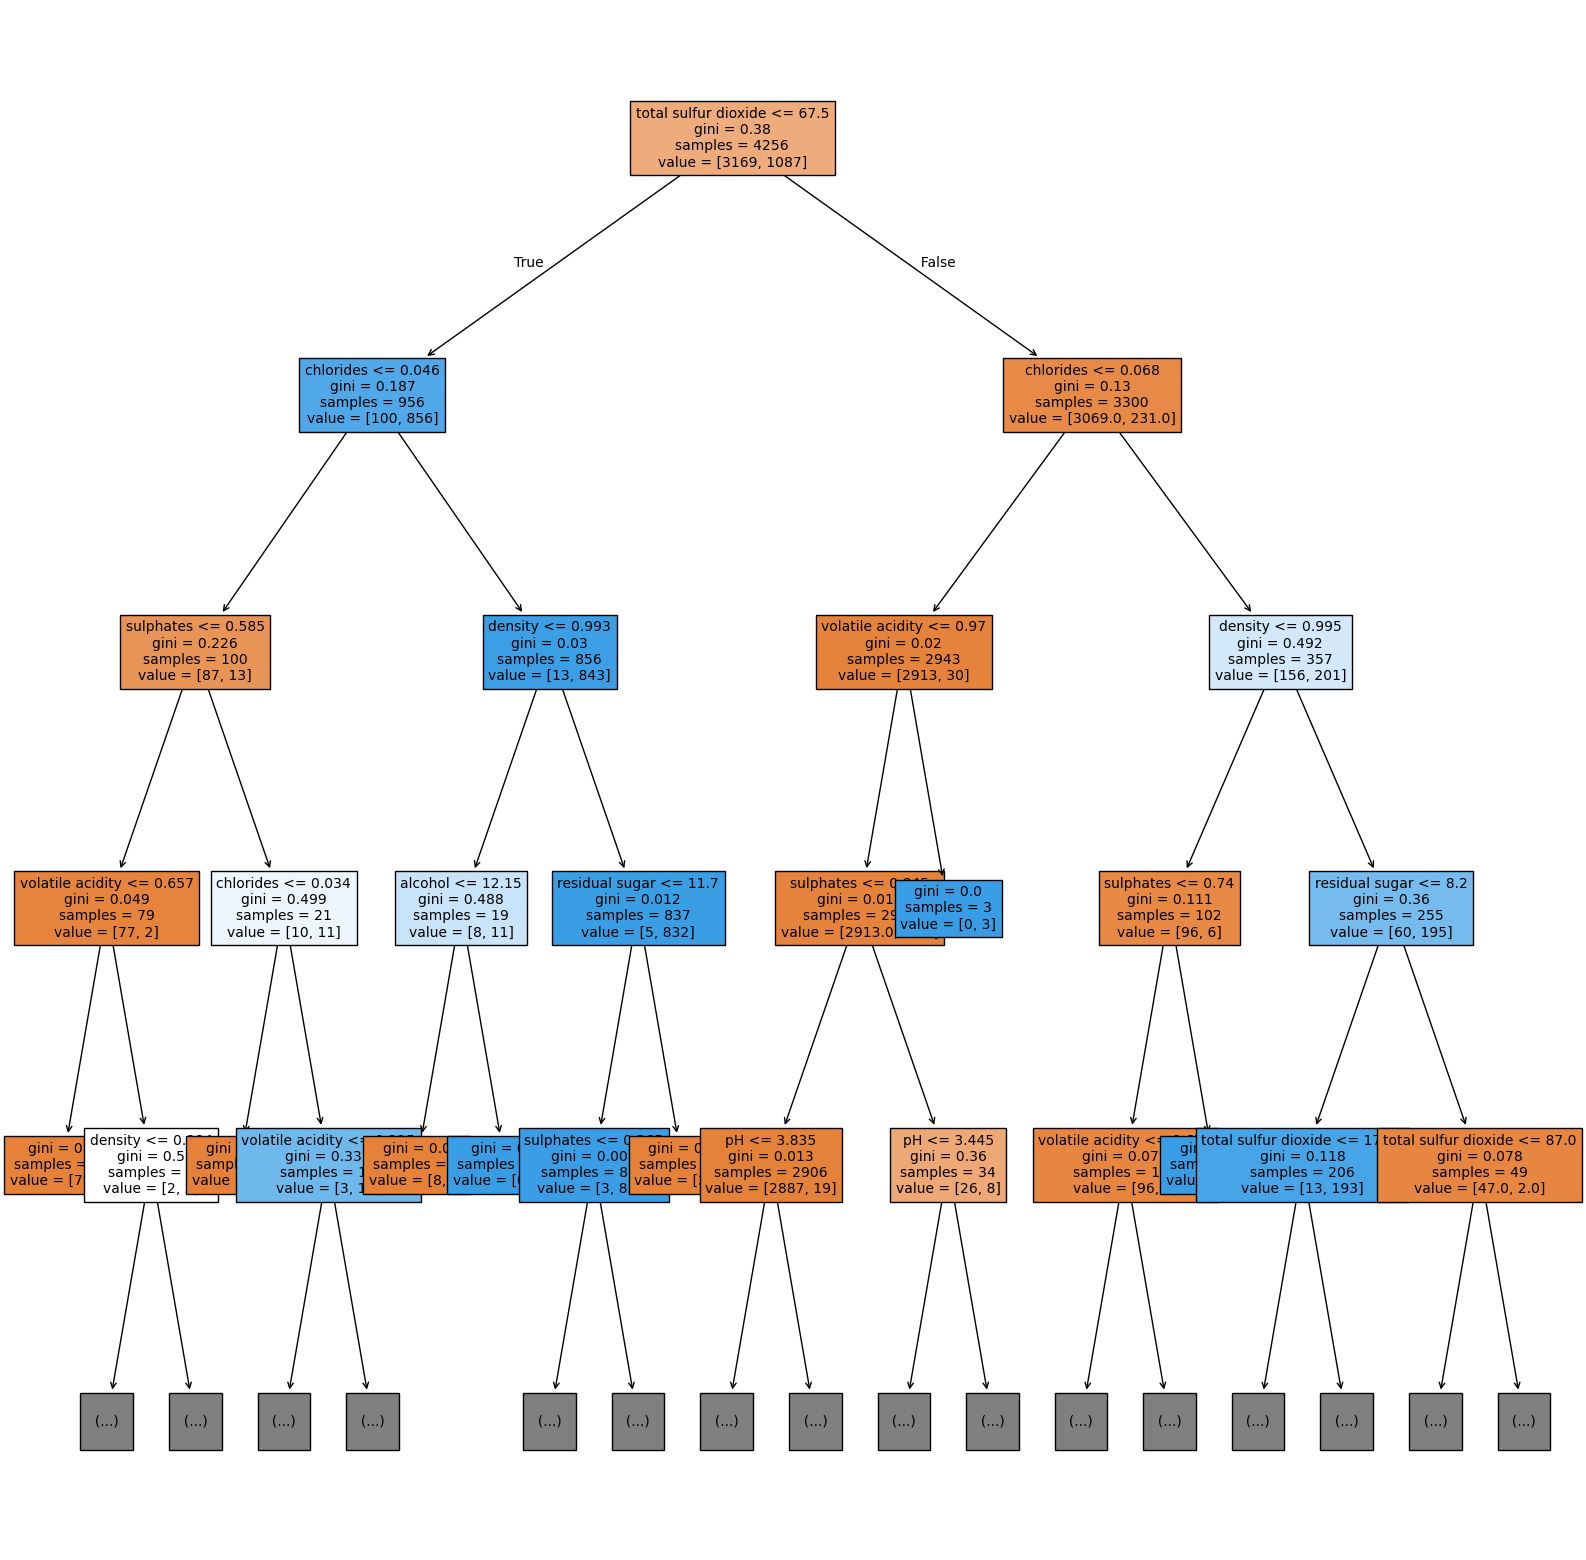

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 20))
tree = plot_tree(model,
                 feature_names=feature_names,
                 max_depth=4,
                 filled=True,
                 fontsize=10)
plt.show()

#### - feature의 중요도 추출하기

In [45]:
model.feature_importances_

array([0.00153589, 0.01506586, 0.00291054, 0.04312228, 0.20904684,
       0.0026289 , 0.64277219, 0.05092935, 0.01160176, 0.01199091,
       0.00839548, 0.        ])

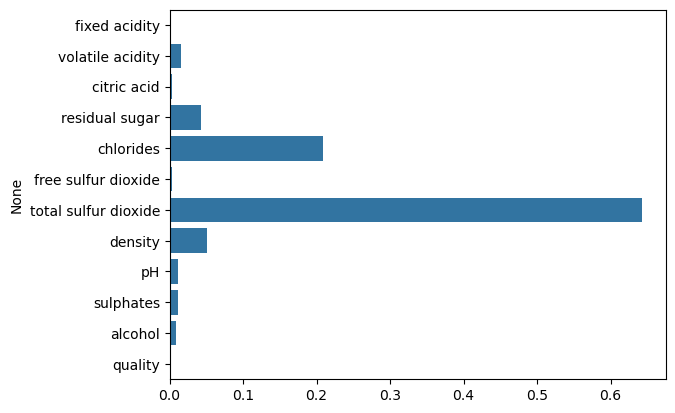

In [46]:
sns.barplot(x=model.feature_importances_, y=feature_names)
plt.show()

total sulfur dioxide, chlorides, density, residual sugar 등의 순서로 주요 특징을 확인할 수 있다.

- 틀린 예측 개수 계산

In [47]:
diff_count = abs(y_test - y_predict).sum()
diff_count

np.int64(22)

- 정확도 직접 계산

In [48]:
(len(y_test) - diff_count) / len(y_test) * 100

np.float64(97.93233082706767)

- sklearn으로 정확도 계산

In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)*100

97.93233082706767

- 모델 자체가 제공하는 정확도 계산

In [50]:
model.score(X_test, y_test) * 100

97.93233082706767

- classification report 출력

In [52]:
from sklearn.metrics import classification_report
pred=model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       792
           1       0.96      0.96      0.96       272

    accuracy                           0.98      1064
   macro avg       0.97      0.97      0.97      1064
weighted avg       0.98      0.98      0.98      1064



- precision: 예측이 맞은 비율
- recall: 실제를 얼마나 맞췄는지
- f1-score: precision + recall 균형
- support: 데이터 수

화이트 98%, 레드 96%로 정답을 맞췄다.<Br>
Decision Tree 모델을 사용하여 와인 종류를 분류한 결과 약 97.9%의 높은 정확도를 보였다.<br>
이는 와인의 화학적 특성이 레드와인과 화이트와인을 구분하는데 유의미한 정보를 제공하는 것을 알 수 있다.